In [29]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, RobustScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

# Prikaz podataka

In [30]:

data_set = pd.read_csv("oasis_test_patients_metadata.csv")

print(data_set)

                ID M/F Hand  Age  Educ  SES  MMSE  CDR  eTIV   nWBV    ASF  \
0    OAS1_0001_MR1   F    R   74   2.0  3.0  29.0  0.0  1344  0.743  1.306   
1    OAS1_0003_MR1   F    R   73   4.0  3.0  27.0  0.5  1454  0.708  1.207   
2    OAS1_0004_MR1   M    R   28   NaN  NaN   NaN  NaN  1588  0.803  1.105   
3    OAS1_0005_MR1   M    R   18   NaN  NaN   NaN  NaN  1737  0.848  1.010   
4    OAS1_0006_MR1   F    R   24   NaN  NaN   NaN  NaN  1131  0.862  1.551   
..             ...  ..  ...  ...   ...  ...   ...  ...   ...    ...    ...   
239  OAS1_0156_MR2   F    R   20   NaN  NaN   NaN  NaN  1577  0.832  1.113   
240  OAS1_0202_MR2   F    R   23   NaN  NaN   NaN  NaN  1548  0.861  1.134   
241  OAS1_0230_MR2   F    R   19   NaN  NaN   NaN  NaN  1577  0.849  1.113   
242  OAS1_0249_MR2   F    R   28   NaN  NaN   NaN  NaN  1215  0.865  1.444   
243  OAS1_0395_MR2   F    R   26   NaN  NaN   NaN  NaN  1283  0.834  1.368   

     Delay             class  
0      NaN       NonDemented  
1

In [31]:
print(data_set.info())
print(data_set.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      244 non-null    object 
 1   M/F     244 non-null    object 
 2   Hand    244 non-null    object 
 3   Age     244 non-null    int64  
 4   Educ    121 non-null    float64
 5   SES     116 non-null    float64
 6   MMSE    121 non-null    float64
 7   CDR     121 non-null    float64
 8   eTIV    244 non-null    int64  
 9   nWBV    244 non-null    float64
 10  ASF     244 non-null    float64
 11  Delay   10 non-null     float64
 12  class   244 non-null    object 
dtypes: float64(7), int64(2), object(4)
memory usage: 24.9+ KB
None
              ID M/F Hand  Age  Educ  SES  MMSE  CDR  eTIV   nWBV    ASF  \
0  OAS1_0001_MR1   F    R   74   2.0  3.0  29.0  0.0  1344  0.743  1.306   
1  OAS1_0003_MR1   F    R   73   4.0  3.0  27.0  0.5  1454  0.708  1.207   
2  OAS1_0004_MR1   M    R   28   NaN  NaN   

### Da li imamo null vrednosti

In [32]:
print(data_set.isnull().sum())

ID         0
M/F        0
Hand       0
Age        0
Educ     123
SES      128
MMSE     123
CDR      123
eTIV       0
nWBV       0
ASF        0
Delay    234
class      0
dtype: int64


In [33]:
missing_counts = data_set.isnull().sum()

missing_percent = (missing_counts / len(data_set)) * 100

for col, pct in missing_percent.items():
    print(f"{col:10} {missing_counts[col]:5} -> ({pct:.1f}%)")

ID             0 -> (0.0%)
M/F            0 -> (0.0%)
Hand           0 -> (0.0%)
Age            0 -> (0.0%)
Educ         123 -> (50.4%)
SES          128 -> (52.5%)
MMSE         123 -> (50.4%)
CDR          123 -> (50.4%)
eTIV           0 -> (0.0%)
nWBV           0 -> (0.0%)
ASF            0 -> (0.0%)
Delay        234 -> (95.9%)
class          0 -> (0.0%)


Da li imamo duplikate

In [34]:
duplicates = data_set.duplicated()
print(data_set[duplicates])
print(f"Broj duplikata:{duplicates.sum()}")

Empty DataFrame
Columns: [ID, M/F, Hand, Age, Educ, SES, MMSE, CDR, eTIV, nWBV, ASF, Delay, class]
Index: []
Broj duplikata:0


### Izbacivanje nepotrebnog polja ID

ID je samo indentifikator i nije potreban za dalji rad.

In [35]:
data_set = data_set.drop(['ID'], axis=1)

### Popunjavanje polja koji nemaju vrednosti medianom

In [36]:
for col in ['Educ', 'SES', 'MMSE', 'CDR']:
    data_set[col] = data_set[col].fillna(data_set[col].median())

In [37]:
print(data_set.isnull().sum())

M/F        0
Hand       0
Age        0
Educ       0
SES        0
MMSE       0
CDR        0
eTIV       0
nWBV       0
ASF        0
Delay    234
class      0
dtype: int64


### Label encoding i One hot encoding

In [38]:
le = LabelEncoder()

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

X_catg = data_set[['M/F', 'Hand']].astype(str)
ohe_result = ohe.fit_transform(X_catg)
feature_names = ohe.get_feature_names_out()  
df_ohe = pd.DataFrame(ohe_result, columns=feature_names, index=data_set.index)

data_set = pd.concat([data_set.drop(['M/F', 'Hand'], axis=1), df_ohe], axis=1)
# data_set['class'] = le.fit_transform(data_set['class']) 

In [39]:
print(data_set.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Age     244 non-null    int64  
 1   Educ    244 non-null    float64
 2   SES     244 non-null    float64
 3   MMSE    244 non-null    float64
 4   CDR     244 non-null    float64
 5   eTIV    244 non-null    int64  
 6   nWBV    244 non-null    float64
 7   ASF     244 non-null    float64
 8   Delay   10 non-null     float64
 9   class   244 non-null    object 
 10  M/F_F   244 non-null    float64
 11  M/F_M   244 non-null    float64
 12  Hand_R  244 non-null    float64
dtypes: float64(10), int64(2), object(1)
memory usage: 24.9+ KB
None


# Poređenje kada data set sadrži Delay i ne sadrži

Kolona Delay sadrži dosta NaN vrednosti. Treba ispitati da li ona utiče na tačnost modela.

In [40]:
data_set['Delay_present'] = data_set['Delay'].notnull().astype(int)


In [41]:
features = data_set.drop(['Delay', 'class'], axis=1)
target = data_set['class']

In [42]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest Accuracy sa Delay_present: {accuracy:.3f}")

Random Forest Accuracy sa Delay_present: 0.959


In [43]:
features_no_delay = features.drop(['Delay_present'], axis=1)

X_train2, X_test2, y_train2, y_test2 = train_test_split(features_no_delay, target, test_size=0.2, random_state=42)

rf_model2 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model2.fit(X_train2, y_train2)

y_pred2 = rf_model2.predict(X_test2)
accuracy_no_delay = accuracy_score(y_test2, y_pred2)
print(f"Accuracy bez Delay_present: {accuracy_no_delay:.3f}")


Accuracy bez Delay_present: 0.959


Kolona Delay sadrži veliki broj nedostajućih vrednosti (NaN). Da bismo procenili njen uticaj na klasifikaciju, kreirali smo binarnu kolonu Delay_present, koja označava da li vrednost Delay postoji (1) ili ne (0). Zatim smo trenirali Random Forest model sa i bez kolone Delay_present. Rezultati su pokazali identičan nivo tačnosti modela (accuracy = 0.959), što ukazuje da prisustvo vrednosti Delay ne doprinosi poboljšanju predikcije. Na osnovu toga, kolonu Delay možemo bezbedno izbaciti iz dataset-a, a da ne izgubimo informaciju relevantnu za model.

In [44]:
data_set = data_set.drop(['Delay_present'], axis=1)

In [45]:
data_set.describe()


,Age,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF,Delay,M/F_F,M/F_M,Hand_R
count,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,10.00000,244.000000,244.000000,244.0
mean,49.368852,3.131148,2.504098,28.512295,0.073770,1486.549180,0.799648,1.195865,18.10000,0.618852,0.381148,1.0
std,24.295235,0.902222,0.783040,2.140116,0.228361,158.661511,0.054888,0.128109,20.11329,0.486667,0.486667,0.0
min,18.000000,1.000000,1.000000,15.000000,0.000000,1131.000000,0.644000,0.920000,1.00000,0.000000,0.000000,1.0
25%,23.000000,3.000000,2.500000,29.000000,0.000000,1369.500000,0.756750,1.104750,3.50000,0.000000,0.000000,1.0
50%,48.000000,3.000000,2.500000,29.000000,0.000000,1476.000000,0.819500,1.190000,11.00000,1.000000,0.000000,1.0
75%,72.000000,3.000000,2.500000,29.000000,0.000000,1590.000000,0.843250,1.283500,23.25000,1.000000,1.000000,1.0
max,94.000000,5.000000,5.000000,30.000000,2.000000,1908.000000,0.893000,1.551000,64.00000,1.000000,1.000000,1.0


### Korelaciona matrica

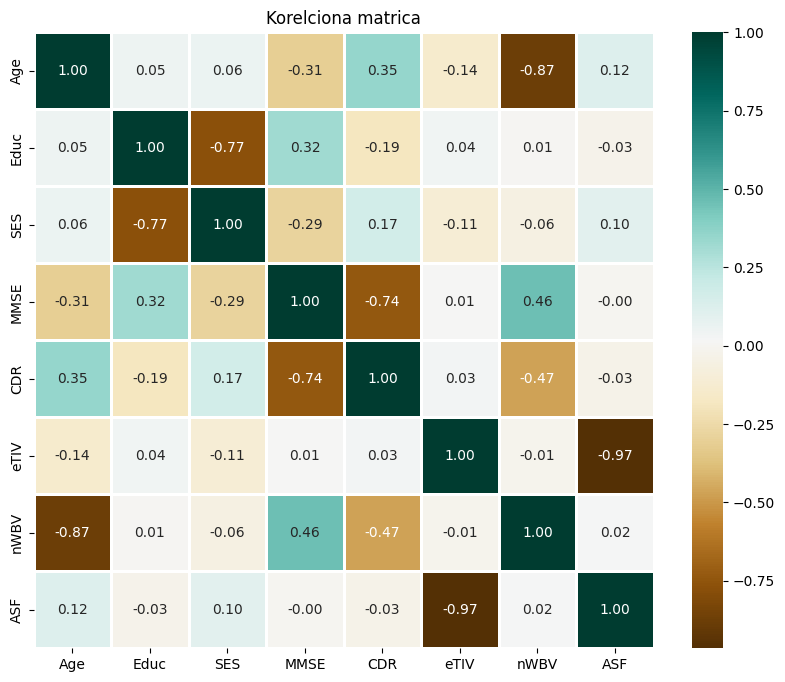

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['Age','Educ','SES','MMSE','CDR','eTIV','nWBV','ASF']
plt.figure(figsize=(10,8))
sns.heatmap(data_set[num_cols].corr(), annot=True, fmt=".2f", cmap='BrBG', linewidths=1)
plt.title("Korelciona matrica")
plt.show()


### Distribucija klasa

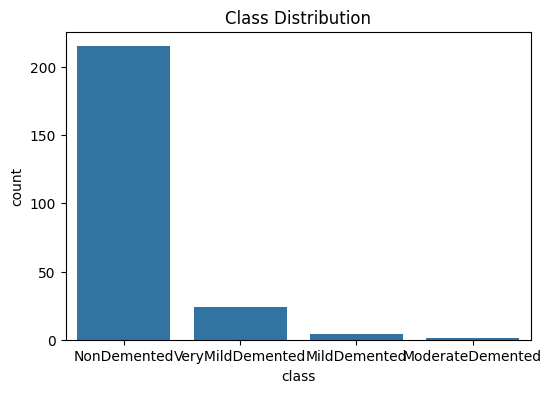

In [47]:
plt.figure(figsize=(6,4))
sns.countplot(x='class', data=data_set)
plt.title("Class Distribution")
plt.show()

In [48]:
X = data_set.drop('class', axis=1)  
y = data_set['class']             

In [49]:
print(y.value_counts())

class
NonDemented         215
VeryMildDemented     24
MildDemented          4
ModerateDemented      1
Name: count, dtype: int64


Binarna klasifikacija -> spajamo kalse u one za NonDemented i Demented

In [50]:
data_set['class_binary'] = data_set['class'].apply(lambda x: 0 if x == 'NonDemented' else 1)

print(data_set['class_binary'].value_counts())


class_binary
0    215
1     29
Name: count, dtype: int64


### Outliers

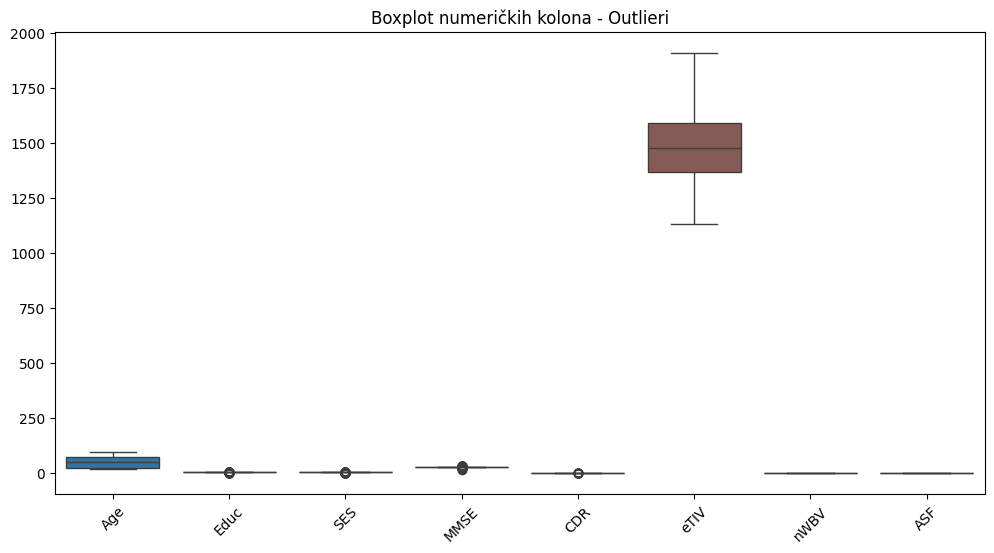

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['Age','Educ','SES','MMSE','CDR','eTIV','nWBV','ASF']

plt.figure(figsize=(12,6))
sns.boxplot(data=data_set[num_cols])
plt.xticks(rotation=45)
plt.title("Boxplot numeričkih kolona - Outlieri")
plt.show()


Skaliranje

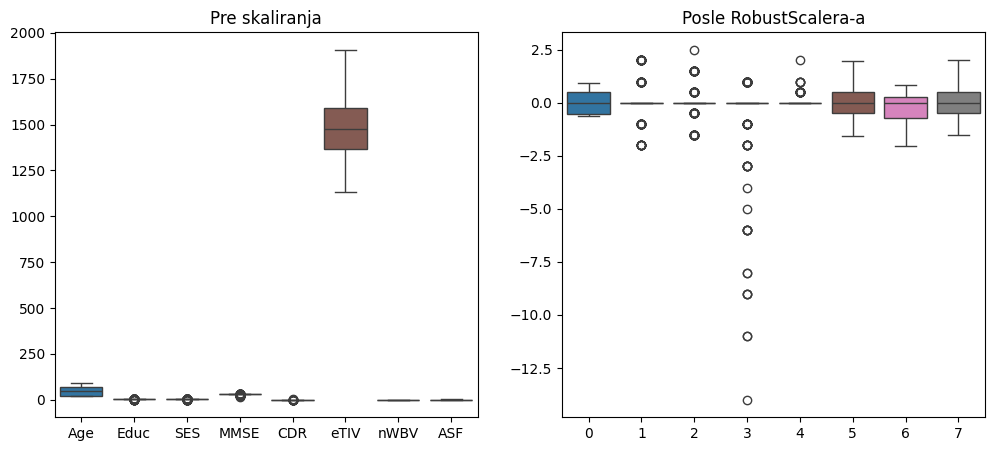

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['Age','Educ','SES','MMSE','CDR','eTIV','nWBV','ASF']

scaler = RobustScaler()
X_scaled = scaler.fit_transform(data_set[num_cols])

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(data=data_set[num_cols])
plt.title("Pre skaliranja")
plt.subplot(1,2,2)
sns.boxplot(data=X_scaled)
plt.title("Posle RobustScalera-a")
plt.show()


Pregled otliera pomoću IQR metode

In [53]:
num_cols = ['Age','Educ','SES','MMSE','CDR','eTIV','nWBV','ASF']

outliers = {}

# IQR method
for col in num_cols:
    Q1 = data_set[col].quantile(0.25)
    Q3 = data_set[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers[col] = data_set[
        (data_set[col] < lower_bound) | (data_set[col] > upper_bound)
    ]


print("Broj outlier-a po koloni:\n")
for col in num_cols:
    print(f"{col}: {outliers[col].shape[0]}")



Broj outlier-a po koloni:

Age: 0
Educ: 94
SES: 116
MMSE: 87
CDR: 29
eTIV: 0
nWBV: 0
ASF: 0


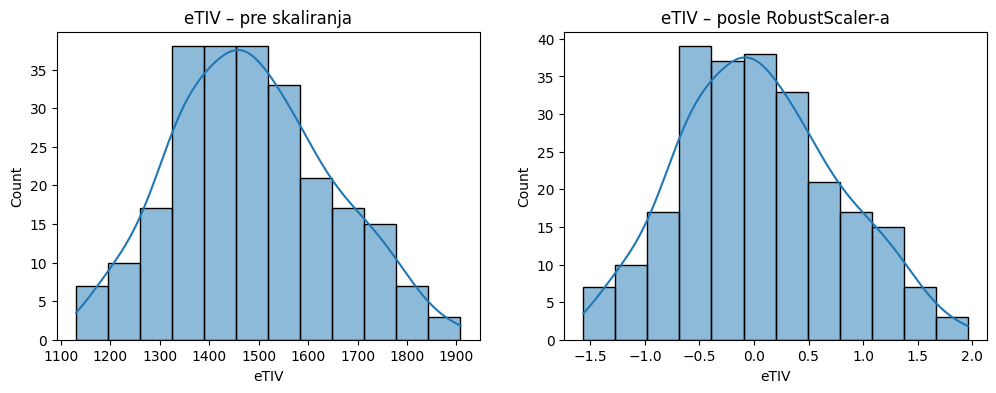

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

col = "eTIV" 

scaled_df = pd.DataFrame(X_scaled, columns=num_cols)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.histplot(data_set[col], kde=True)
plt.title(f"{col} – pre skaliranja")

plt.subplot(1,2,2)
sns.histplot(scaled_df[col], kde=True)
plt.title(f"{col} – posle RobustScaler-a")

plt.show()


Baseline model?

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


num_cols = ['Age','Educ','SES','MMSE','CDR','eTIV','nWBV','ASF']

X = data_set[num_cols]
y = data_set['class_binary']


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)

print("====== Dummy Classifier ======")
print("Accuracy :", accuracy_score(y_test, y_pred_dummy))
print("Precision:", precision_score(y_test, y_pred_dummy, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_dummy))
print("F1-score :", f1_score(y_test, y_pred_dummy))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dummy))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dummy))



scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'  
)

log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)

print("\n====== Logistic Regression ======")
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1-score :", f1_score(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))


====== Dummy Classifier ======
Accuracy : 0.8775510204081632
Precision: 0.0
Recall   : 0.0
F1-score : 0.0
Confusion Matrix:
 [[43  0]
 [ 6  0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      1.00      0.93        43
           1       0.00      0.00      0.00         6

    accuracy                           0.88        49
   macro avg       0.44      0.50      0.47        49
weighted avg       0.77      0.88      0.82        49


====== Logistic Regression ======
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0
Confusion Matrix:
 [[43  0]
 [ 0  6]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        43
           1       1.00      1.00      1.00         6

    accuracy                           1.00        49
   macro avg       1.00      1.00      1.00        49
weighted avg       1.00      1.00      1.00        49



d:\Master\ML\Project_1\Machine_Learning_Project_1\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Master\ML\Project_1\Machine_Learning_Project_1\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Master\ML\Project_1\Machine_Learning_Project_1\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

Cross validation za Logistic Regression

In [57]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('lr', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

f1_scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=cv,
    scoring='f1'
)

print("F1 scores per fold:", f1_scores)
print("Mean F1:", f1_scores.mean())
print("Std F1:", f1_scores.std())


F1 scores per fold: [0.71428571 0.85714286 0.85714286 0.92307692 1.        ]
Mean F1: 0.8703296703296702
Std F1: 0.09412137628731367


In [58]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

f1_scores_rf = cross_val_score(rf, X, y, cv=cv, scoring='f1')

print("Random Forest F1 per fold:", f1_scores_rf)
print("Mean F1:", f1_scores_rf.mean())
print("Std F1:", f1_scores_rf.std())


Random Forest F1 per fold: [1. 1. 1. 1. 1.]
Mean F1: 1.0
Std F1: 0.0


In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
import numpy as np

# Pipeline sa skaliranjem
lr_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('lr', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f1_scores_lr = cross_val_score(lr_pipeline, X, y, cv=cv, scoring='f1')

print("=== Logistic Regression ===")
print("F1 per fold:", np.round(f1_scores_lr,3))
print("Mean F1:", round(f1_scores_lr.mean(),3))
print("Std F1:", round(f1_scores_lr.std(),3))


=== Logistic Regression ===
F1 per fold: [0.714 0.857 0.857 0.923 1.   ]
Mean F1: 0.87
Std F1: 0.094


In [60]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
f1_scores_dt = cross_val_score(dt_model, X, y, cv=cv, scoring='f1')

print("\n=== Decision Tree ===")
print("F1 per fold:", np.round(f1_scores_dt,3))
print("Mean F1:", round(f1_scores_dt.mean(),3))
print("Std F1:", round(f1_scores_dt.std(),3))



=== Decision Tree ===
F1 per fold: [1. 1. 1. 1. 1.]
Mean F1: 1.0
Std F1: 0.0


In [61]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

svm_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('svc', SVC(kernel='rbf', class_weight='balanced'))
])

f1_scores_svm = cross_val_score(svm_pipeline, X, y, cv=cv, scoring='f1')

print("\n=== SVM ===")
print("F1 per fold:", np.round(f1_scores_svm,3))
print("Mean F1:", round(f1_scores_svm.mean(),3))
print("Std F1:", round(f1_scores_svm.std(),3))



=== SVM ===
F1 per fold: [0.615 0.625 0.714 0.556 0.556]
Mean F1: 0.613
Std F1: 0.058


In [62]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

knn_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

f1_scores_knn = cross_val_score(knn_pipeline, X, y, cv=cv, scoring='f1')

print("\n=== kNN ===")
print("F1 per fold:", np.round(f1_scores_knn,3))
print("Mean F1:", round(f1_scores_knn.mean(),3))
print("Std F1:", round(f1_scores_knn.std(),3))



=== kNN ===
F1 per fold: [0.545 0.5   0.286 0.909 0.75 ]
Mean F1: 0.598
Std F1: 0.214
